# Visualização — População por UF (IBGE/SIDRA)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PASTA = Path('/home/gabyl/projetos/Projeto-Caramujo/data/populacao/ufs')

## 1. Listar arquivos disponíveis

In [2]:
arquivos = sorted(PASTA.glob('pop_ufs_*.parquet'))
print(f'{len(arquivos)} arquivos encontrados:')
for a in arquivos:
    print(' ', a.name)

15 arquivos encontrados:
  pop_ufs_2008.parquet
  pop_ufs_2009.parquet
  pop_ufs_2011.parquet
  pop_ufs_2012.parquet
  pop_ufs_2013.parquet
  pop_ufs_2014.parquet
  pop_ufs_2015.parquet
  pop_ufs_2016.parquet
  pop_ufs_2017.parquet
  pop_ufs_2018.parquet
  pop_ufs_2019.parquet
  pop_ufs_2020.parquet
  pop_ufs_2021.parquet
  pop_ufs_2024.parquet
  pop_ufs_2025.parquet


## 2. Abrir um único arquivo

In [3]:
df_2014 = pd.read_parquet(PASTA / 'pop_ufs_2014.parquet')
print(df_2014.shape)
df_2014.head(27)

(27, 4)


,code_state,nome_uf,populacao,ano
0,11,Rondônia,1748531,2014
1,12,Acre,790101,2014
2,13,Amazonas,3873743,2014
3,14,Roraima,496936,2014
4,15,Pará,8073924,2014
5,16,Amapá,750912,2014
6,17,Tocantins,1496880,2014
7,21,Maranhão,6850884,2014
8,22,Piauí,3194718,2014
9,23,Ceará,8842791,2014


## 3. Carregar todos os anos em um único DataFrame

In [4]:
df_all = pd.concat([pd.read_parquet(a) for a in arquivos], ignore_index=True)
df_all['ano'] = df_all['ano'].astype(int)
print(f'Total de linhas: {len(df_all)}')
print(f'Anos disponíveis: {sorted(df_all["ano"].unique().tolist())}')
df_all.head()

Total de linhas: 405
Anos disponíveis: [2008, 2009, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2024, 2025]


,code_state,nome_uf,populacao,ano
0,11,Rondônia,1493565,2008
1,12,Acre,680075,2008
2,13,Amazonas,3341094,2008
3,14,Roraima,412783,2008
4,15,Pará,7321490,2008


## 4. Estatísticas resumidas por ano

In [5]:
resumo = (
    df_all.groupby('ano')['populacao']
    .agg(total='sum', media='mean', max='max', min='min')
    .reset_index()
)
resumo['total'] = resumo['total'].map('{:,.0f}'.format)
resumo['media'] = resumo['media'].map('{:,.0f}'.format)
resumo['max'] = resumo['max'].map('{:,.0f}'.format)
resumo['min'] = resumo['min'].map('{:,.0f}'.format)
resumo

,ano,total,media,max,min
0,2008,"189,605,006","7,022,408","41,011,638","412,783"
1,2009,"191,480,630","7,091,875","41,384,039","421,499"
2,2011,"192,379,287","7,125,159","41,587,182","460,165"
3,2012,"193,904,015","7,181,630","41,901,219","469,524"
4,2013,"201,032,714","7,445,656","43,663,669","488,072"
5,2014,"202,768,562","7,509,947","44,035,304","496,936"
6,2015,"204,450,049","7,572,224","44,396,484","505,665"
7,2016,"206,081,432","7,632,646","44,749,699","514,229"
8,2017,"207,660,929","7,691,146","45,094,866","522,636"
9,2018,"208,494,900","7,722,033","45,538,936","576,568"


## 5. Gráfico — Evolução da população total do Brasil por ano

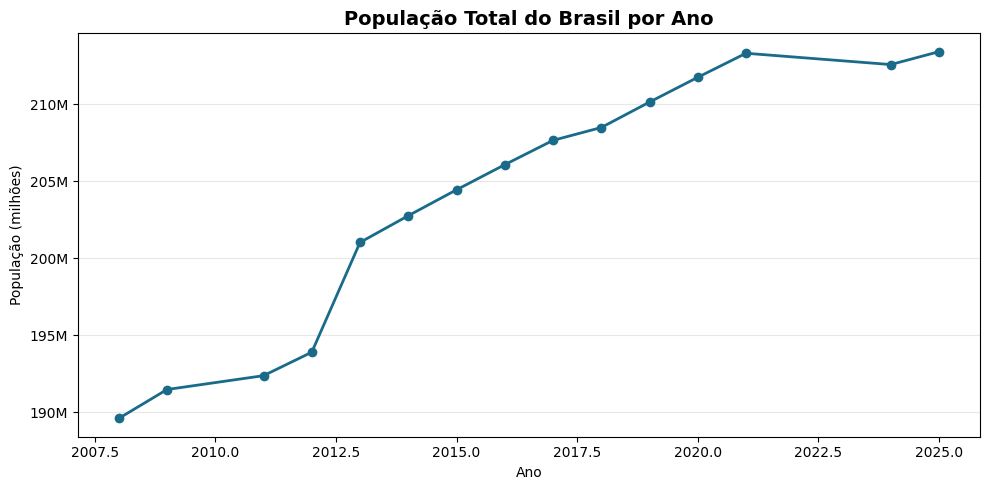

In [6]:
pop_brasil = df_all.groupby('ano')['populacao'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pop_brasil['ano'], pop_brasil['populacao'] / 1e6, marker='o', linewidth=2, color='#1a6b8a')
ax.set_title('População Total do Brasil por Ano', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('População (milhões)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Gráfico — Top 10 UFs mais populosas (ano específico)

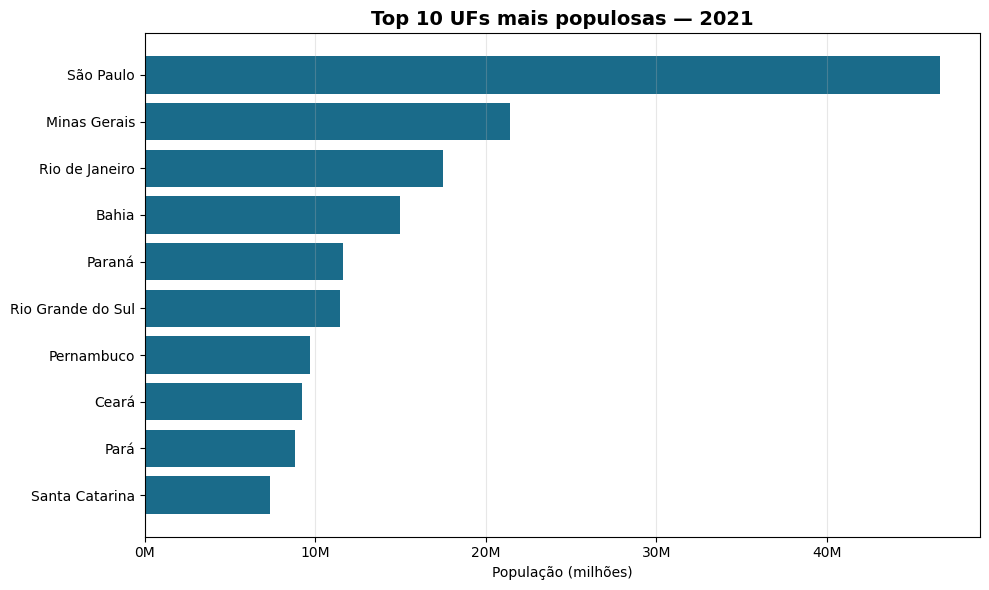

In [7]:
ANO = 2021  # altere aqui

df_ano = df_all[df_all['ano'] == ANO].sort_values('populacao', ascending=True).tail(10)
nome_col = 'nome_uf' if 'nome_uf' in df_ano.columns else 'code_state'

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_ano[nome_col], df_ano['populacao'] / 1e6, color='#1a6b8a')
ax.set_title(f'Top 10 UFs mais populosas — {ANO}', fontsize=14, fontweight='bold')
ax.set_xlabel('População (milhões)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Gráfico — Evolução de UFs específicas ao longo do tempo

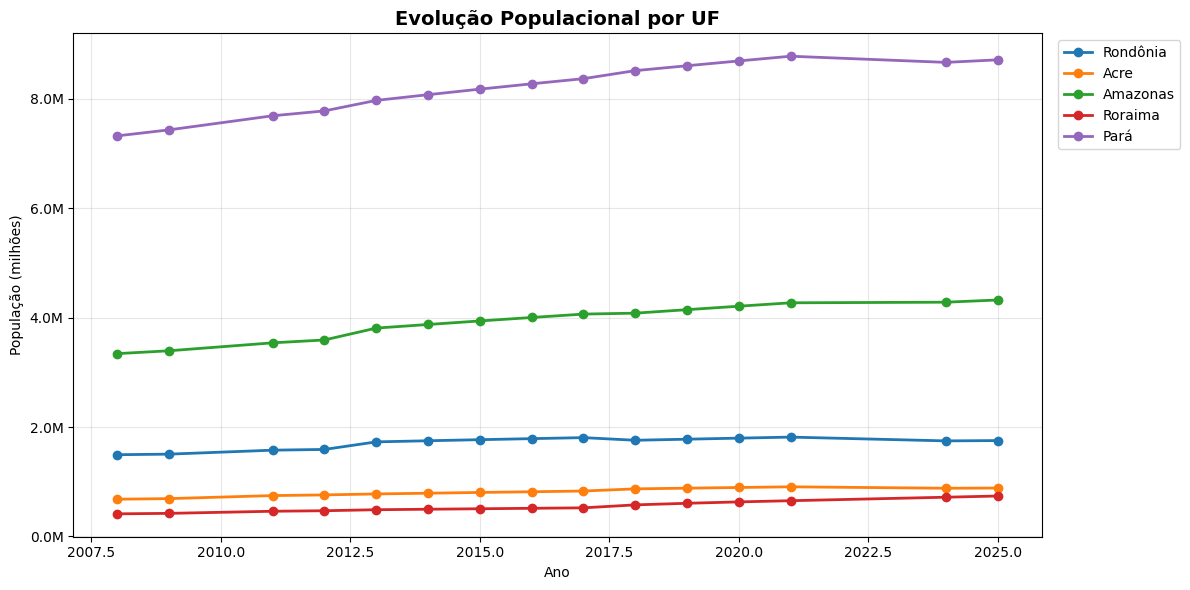

In [8]:
# Altere a lista de UFs conforme necessário
nome_col = 'nome_uf' if 'nome_uf' in df_all.columns else 'code_state'
UFS = df_all[nome_col].dropna().unique()[:5].tolist()  # pega as 5 primeiras por padrão

fig, ax = plt.subplots(figsize=(12, 6))
for uf in UFS:
    serie = df_all[df_all[nome_col] == uf].sort_values('ano')
    ax.plot(serie['ano'], serie['populacao'] / 1e6, marker='o', label=uf, linewidth=2)

ax.set_title('Evolução Populacional por UF', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('População (milhões)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()